<a href="https://colab.research.google.com/github/Trixxzer/PrajwolShrestha_2418111_AIML_Worksheets/blob/main/worksheet3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Task - 1: Implementation of MCP Neurons:</h1>

<h2>AND Operation</h2>

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This functions implements basic AND operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1 nd array): An array of binary values.
    X2 (1 nd array): An array of binary values.
    Output:
    state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
    """
    assert len(X1) == len(X2)
    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let’s name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    state_neuron = []
    for x1, x2 in zip(X1, X2):
        if x1 + x2 >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)
    return state_neuron

In [ ]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2 # Threshold value
# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)
# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


<h2>OR Operations</h2>

In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
        ### YOUR CODE HERE ###
        # Perform an element wise addition of two input arrays stored in a new array(list):
        # Create a new array to put all the prediction let’s name that a state_neuron.
        # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    state_neuron = []

    for x1, x2 in zip(X1, X2):
        if x1 + x2 >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)
    return state_neuron

In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1 # Threshold value for OR gate
# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)
# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


<h3>Question - 1: List out all the limitations of MCP - Neurons.</h3>

<h3>->Binary inputs and outputs only
Limited to linear problems
Hard threshold</h3>

<h3>Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
{Can you devise a if else rules.}</h3>

<h1>Task 2: Perceptron Algorithm for 0 vs 1 Classification.</h1>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load the dataset
df_0_1 = pd.read_csv("mnist_0_and_1.csv") # Add the correct file path if necessary
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (5216, 784)
Label vector shape: (5216,)


<h3>Question - 1: What does the shape of X represent?</h3>

<h3>->Represents the dimension of the feature matrix</h3>

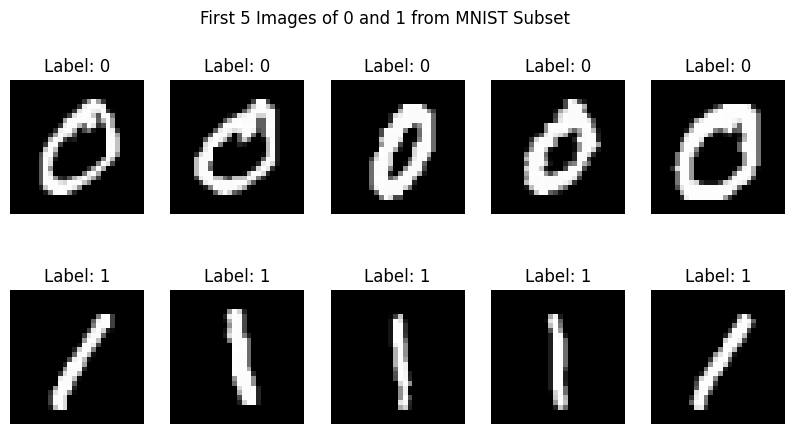

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 0] # Get all images with label 0
images_1 = X[y == 1] # Get all images with label 1
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

<h3>Question - 3: What does the weights array represent in this context?</h3>

<h3>-> Represents a weight for each pixel</h3>

<h3>Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?</h3>

<h3>->Common way of initialising the weights</h3>
<h3>->It effects the training process by slower convergence sometimes</h3>

In [ ]:
def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.
    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training
    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    y_prob = 1 / (1 + np.exp(-predictions))
    y_pred_all = (y_prob >= 0.5).astype(int)
    #####Your Code Here############ # Activation function (step function)
    return y_pred_all

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=10):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    """
    for epoch in range(epochs):
        for i in range(len(X)):
            # Step function: 0 if <0, else 1
            linear_output = np.dot(X[i], weights) + bias
            y_pred = 1 if linear_output >= 0 else 0

            # Update weights and bias
            update = learning_rate * (y[i] - y_pred)
            weights += update * X[i]
            bias += update

    # Compute final predictions and accuracy
    linear_output_all = np.dot(X, weights) + bias
    y_pred_all = (linear_output_all >= 0).astype(int)
    accuracy = np.mean(y_pred_all == y)

    return weights, bias, accuracy

<h3>Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?</h3>

<h3>-> Does the core computation for the neuorn, inshort calculates Z</h3>

<h3>Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?</h3>

<h3>->Adjusts the weights and bias to reduce future errors,weights and biases are updated through Gradient descent</h3>

<h3>Question - 7:Why is the final accuracy important, and what do you expect it to be?</h3>

<h3>Final accuracy is important because it helps us review the models over all performance, it expect it around ~80%</h3>

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  0.4652990797546012


Final Accuracy: 0.4653


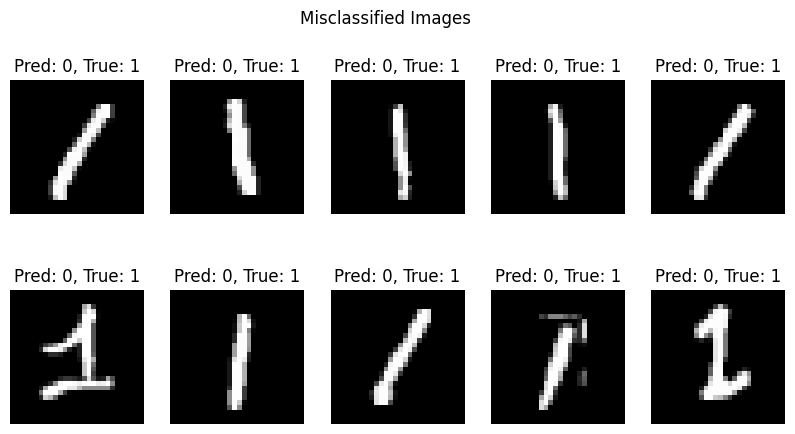

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
        plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

<h3>Question - 8:What does misclassified idx store, and how is it used in this code?</h3>

<h3>-> It checks that y_true is equals to y_pred(predicted by model</h3>

<h3>Question - 9: How do you interpret the result if the output is ”All images were
correctly classified!”?</h3>

<h3>-> All outputs are correct!! 100% accuracy</h3>

<h1>Task 3: Perceptron Algorithm for 3 vs 5 Classification</h1>

In [ ]:
# Load the dataset
df_0_2 = pd.read_csv("mnist_3_and_5.csv") # Add the correct file path if necessary
# Extract features and labels
X_second = df_0_2.drop(columns=["label"]).values # 784 pixels
y_second = df_0_2["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (5216, 784)
Label vector shape: (5216,)


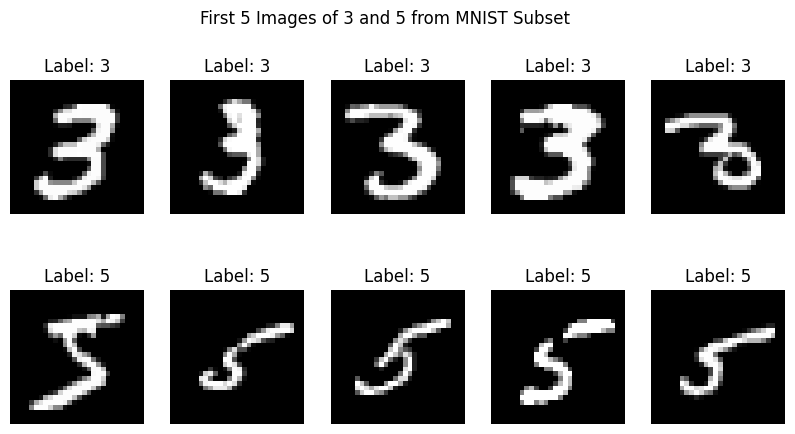

In [ ]:
# Separate images for label 3 and label 5
images_0 = X_second[y_second == 3] # Get all images with label 3
images_1 = X_second[y_second == 5] # Get all images with label 5
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.show()

In [ ]:
# Initialize weights and bias
weights = np.zeros(X_second.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

In [ ]:
y_second = np.where(y_second == 3, 0, 1)
weights = np.zeros(X_second.shape[1])

# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X_second, y_second, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  0.5421157684630739


Final Accuracy: 0.5421


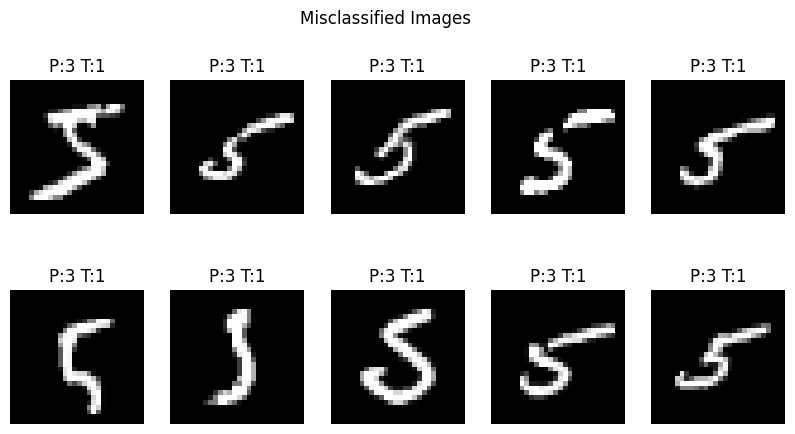

In [ ]:
# Convert labels: 3 -> 0, 5 -> 1
y_binary = y_second

# ===== Predictions =====
predictions = np.dot(X_second, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Accuracy (correct comparison)
final_accuracy = np.mean(y_pred == y_binary)
print(f"Final Accuracy: {final_accuracy:.4f}")


# ===== Convert for visualization only =====
y_pred_labels = np.where(y_pred == 0, 3, 5)


# ===== Misclassified Images =====
misclassified_idx = np.where(y_pred != y_binary)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    # Turn off all axes first (clean look)
    for ax in axes.flat:
        ax.axis("off")

    # Plot up to 10 misclassified images
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X_second[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"P:{y_pred_labels[idx]} T:{y_second[idx]}")

    plt.suptitle("Misclassified Images")
    plt.show()

else:
    print("All images were correctly classified!")